In [1]:
!pip install -U transformers accelerate torch torchvision pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.1/553.1 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/2

In [1]:
import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForMultimodalLM

In [6]:
model_id = "Salesforce/blip-image-captioning-base"

processor = AutoProcessor.from_pretrained(model_id)

model = AutoModelForMultimodalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

model = model.to("cpu")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Saving Screenshot 2025-09-18 124708.png to Screenshot 2025-09-18 124708.png


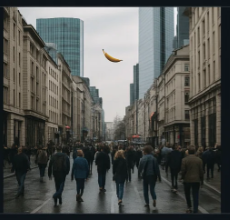

In [10]:
from google.colab import files

uploaded = files.upload()

image_path = next(iter(uploaded))
image = Image.open(image_path).convert("RGB")

image

In [11]:
inputs = processor(
    images=image,
    return_tensors="pt"
).to("cpu", torch.float16)

output = model.generate(
    **inputs,
    max_new_tokens=50
)

caption = processor.decode(
    output[0],
    skip_special_tokens=True
)

print("Generated Caption:")
print(caption)

Generated Caption:
a yellow balloon flying over a city street


Other Model

In [12]:
!pip install -U git+https://github.com/huggingface/transformers accelerate qwen-vl-utils

  Cloning https://github.com/huggingface/transformers to /tmp/pip-req-build-4pgr995a
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers /tmp/pip-req-build-4pgr995a
  Resolved https://github.com/huggingface/transformers to commit 4a2e450e601214024c8a37abdaca35df2a4a3ba3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 12.0 MB/s eta 0:00:00
  Created wheel for transformers: filename=transformers-5.16.0.dev0-py3-none-any.whl size=13442581 sha256=1265593a97a345a314362d8233077906aa85b6443a9d30d7c36582e609020661
  Stored in directory: /tmp/pip-ephem-wheel-cache-3rcgvs8c/wheels/2b/de/48/1c5b158806820c3979e1dc7a341b68dac1231f00b1a2c9442f
Successfully built transformers
  Attempting uninstall: transformers
    Found existing installation: transformers 5.16.1
    Uninstalling transformers-5.16.1:
      Succe

In [1]:
import torch
from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor
)

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(model_id)

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

In [11]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": "/content/Screenshot 2025-09-18 124708.png",
            },
            {
                "type": "text",
                "text": "Describe this image in detail."
            }
        ]
    }
]

In [14]:
text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

from qwen_vl_utils import process_vision_info

image_inputs, video_inputs = process_vision_info(messages)

inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)

inputs = inputs.to("cpu")

generated_ids = model.generate(
    **inputs,
    max_new_tokens=200
)

generated_ids_trimmed = [
    out_ids[len(in_ids):]
    for in_ids, out_ids in zip(
        inputs.input_ids,
        generated_ids
    )
]

output_text = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True
)

print(output_text[0])

KeyboardInterrupt: 